In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
# Directory = r'D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing'
# os.chdir(Directory)
pwd = os.getcwd()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

REPO_ROOT = Path(pwd).resolve().parents[1]
WORKDIR = REPO_ROOT / "scripts" / "RingMod_Squeezing"
os.chdir(WORKDIR)
print("Current working directory:", os.getcwd())

# --- Save directory ---
data_save_dir = REPO_ROOT / "results_data" / "Data_RingMod_QuantumComb"
data_save_dir.mkdir(parents=True, exist_ok=True)
print("Data will be saved to:", data_save_dir)

assert WORKDIR.exists(), "WORKDIR does not exist"
assert data_save_dir.exists(), "Data save dir not created"

Current working directory: D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing
Data will be saved to: D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_QuantumComb


In [2]:
neff = 1.5277
L = 2 * np.pi * 60E-6 
lambda0 = 1550E-9

M = int(neff * L / lambda0)
print("M =", M)

M = 371


In [3]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'RingMOD_Squeez.lms' # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()
f.switchtolayout()

Starting new Lumerical MODE session...


In [4]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart    = 1549E-9
LambdaStop     = 1553E-9

Width          = 1500E-9
Height         = 200E-9
Radius         = 100E-6
GapIO          = 1200E-9
GapRing        = 1000E-9
Length         = 4 * Radius
Material       = "Si3N4 (Silicon Nitride) - Luke"
CouplingLengthX = 0E-6
CouplingLengthY = 0E-6
Index          = 2; #optional
decay_time     = 1E-4
BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 1200E-12
# FrequencyPoints    = 2*10000; #for monitors 
FrequencyPoints    = round(1000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 4000


In [5]:
#------------------------------------------------------------
# STRUCTURE GROUP : Ring 
#------------------------------------------------------------

group_name = "Ring Resonator Group"
f.addstructuregroup()
f.set("name", group_name)
f.set("construction group", 1)
f.set("x",0)
f.set("y",0)
f.set("z",0)

f.adduserprop("Width",          2, Width)
f.adduserprop("Height",         2, Height)
f.adduserprop("Radius",         2, Radius)
f.adduserprop("GapIO",          2, GapIO)
f.adduserprop("GapRing",        2, GapRing)
f.adduserprop("Length",         2, Length)
f.adduserprop("Material",       5, Material)
f.adduserprop("Index",          0, Index)
f.adduserprop("CouplingLengthX", 2, CouplingLengthX)
f.adduserprop("CouplingLengthY", 2, CouplingLengthY)

#------------------------------------------------------------
# GEOMETRY SETUP SCRIPT
#------------------------------------------------------------

setup_script = f"""
# Ring half-height and offset so gap center sits at y=0
Yoffset = CouplingLengthY/2 + Radius;
half_sep = (CouplingLengthY + 2*Radius + Width + GapRing) / 2;

# --- RING 1 (centered at y = +half_sep) ---
addrect;
set('name', 'Coupling_up');
set('x', 0); 
set('x span', CouplingLengthX); 
set('y span', Width);
set('y', half_sep + Yoffset);

copy;
set('name', 'Coupling_down');
set('y', half_sep - Yoffset);

addrect;
set('name', 'Straight_right');
set('x', CouplingLengthX/2 + Radius); set('y', half_sep);
set('x span', Width); set('y span', CouplingLengthY);

copy;
set('name', 'Straight_left');
set('x', -(CouplingLengthX/2 + Radius));

addring;
set('name', 'bend_TR');
set('x', CouplingLengthX/2); set('y', half_sep + CouplingLengthY/2);
set('theta start', 0); set('theta stop', 90);
set('inner radius', Radius - Width/2); set('outer radius', Radius + Width/2);

copy;
set('name', 'bend_BR');
set('y', half_sep - CouplingLengthY/2);
set('theta start', -90); set('theta stop', 0);

copy;
set('name', 'bend_TL');
set('x', -CouplingLengthX/2); set('y', half_sep + CouplingLengthY/2);
set('theta start', 90); set('theta stop', 180);

copy;
set('name', 'bend_BL');
set('y', half_sep - CouplingLengthY/2);
set('theta start', 180); set('theta stop', 270);

# --- RING 2: copy all, shift down by 2*half_sep ---

ring_shift = -2*half_sep;
select('Coupling_up');    copy(0, ring_shift, 0); set('name', 'Coupling_up_2');
select('Coupling_down');  copy(0, ring_shift, 0); set('name', 'Coupling_down_2');
select('Straight_right'); copy(0, ring_shift, 0); set('name', 'Straight_right_2');
select('Straight_left');  copy(0, ring_shift, 0); set('name', 'Straight_left_2');
select('bend_TR');        copy(0, ring_shift, 0); set('name', 'bend_TR_2');
select('bend_BR');        copy(0, ring_shift, 0); set('name', 'bend_BR_2');
select('bend_TL');        copy(0, ring_shift, 0); set('name', 'bend_TL_2');
select('bend_BL');        copy(0, ring_shift, 0); set('name', 'bend_BL_2');

# --- BUS WAVEGUIDES (top & bottom only) ---
wg_y = half_sep + Yoffset + GapIO + Width;

addrect;
set('name', 'WG1');
set('x', 0); set('x span', Length); set('y span', Width);
set('y', wg_y);

copy;
set('name', 'WG2');
set('y', -wg_y);

# Assign materials & finalize
selectall;
set('material', Material);
if (Material == '<Object defined dielectric>') {{
    set('index', Index);
}}
set('z min', 0);
set('z max', Height);
"""

f.set("script", setup_script)

#------------------------------------------------------------
# Derived positions (Python side)
#------------------------------------------------------------

Yoffset = CouplingLengthY/2 + Radius
# half_sep = (CouplingLengthY + 2*Radius + Width + GapIO) / 2
half_sep = (CouplingLengthY + 2*Radius + Width + GapRing) / 2
wg_y = half_sep + Yoffset + GapIO + Width

#------------------------------------------------------------
# VarFDTD
#------------------------------------------------------------
FdtdSpanX = 3 * Radius + CouplingLengthX/2
FdtdSpanY = 2 * (wg_y + Width)

f.addvarfdtd()
f.set("simulation time", SimulationTime)
f.set("x0", -Radius - CouplingLengthX/2)
f.set("y0", -wg_y+half_sep)
f.set("x", 0)
f.set("x span", FdtdSpanX)
f.set("y", 0)
f.set("y span", FdtdSpanY)
f.set("z", Height / 2)
f.set("z span", 8*Height)
f.set("background material", BackgroundMaterial)
f.set("set simulation bandwidth", 1)
f.set("bandwidth", 'broadband')
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min", decay_time)

f.set("x min bc", "PML")
f.set("x max bc", "PML")
f.set("y min bc", "PML")
f.set("y max bc", "PML")
f.set("z min bc", "PML")
f.set("z max bc", "PML")

# Test points on ring 1
theta = [45, 135, 225, 315]
test_points = np.zeros((2, 4))
for i in range(4):
    angle_rad = theta[i] * np.pi / 180
    test_points[0, i] = Radius * np.cos(angle_rad)
    test_points[1, i] = half_sep + Radius * np.sin(angle_rad)
f.set("test points", test_points)

#------------------------------------------------------------
# Source (on WG1)
#------------------------------------------------------------
f.addplane()
f.set("name", "PlaneWaveSource")
f.set("injection axis", "x-axis")
f.set("x", -Radius - CouplingLengthX/2)
f.set("y", wg_y)
f.set("y span", Width)
f.set("use relative coordinates", 1)
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)

#------------------------------------------------------------
# Monitors
#------------------------------------------------------------
# THROUGH (output end of WG1)
f.adddftmonitor()
f.set("name", "Through")
f.set("monitor type", "Linear Y")
f.set("x", Radius + CouplingLengthX/2)
f.set("y", wg_y)
f.set("y span", 2 * Width)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

# DROP (output end of WG2)
f.adddftmonitor()
f.set("name", "Drop")
f.set("monitor type", "Linear Y")
f.set("x", -Radius - CouplingLengthX/2)
f.set("y", -wg_y)
f.set("y span", 2 * Width)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

In [ ]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------
f.run()

Wavelength range: 1553.00 nm to 1547.00 nm
Peaks: [1550.3708464  1550.27779162]
Average FSR: 0.09 nm


C:\Users\smmit\AppData\Local\Temp\ipykernel_41968\418242686.py:41: RuntimeWarning: invalid value encountered in log10
  plt.plot(Wavelength*1e6, 10*np.log10(Transmission_drop),    label='Drop (dB)')
C:\Users\smmit\AppData\Local\Temp\ipykernel_41968\418242686.py:62: RuntimeWarning: invalid value encountered in log10
  plt.plot(Frequency*1e-12, 10*np.log10(Transmission_drop),    label='Drop (dB)')


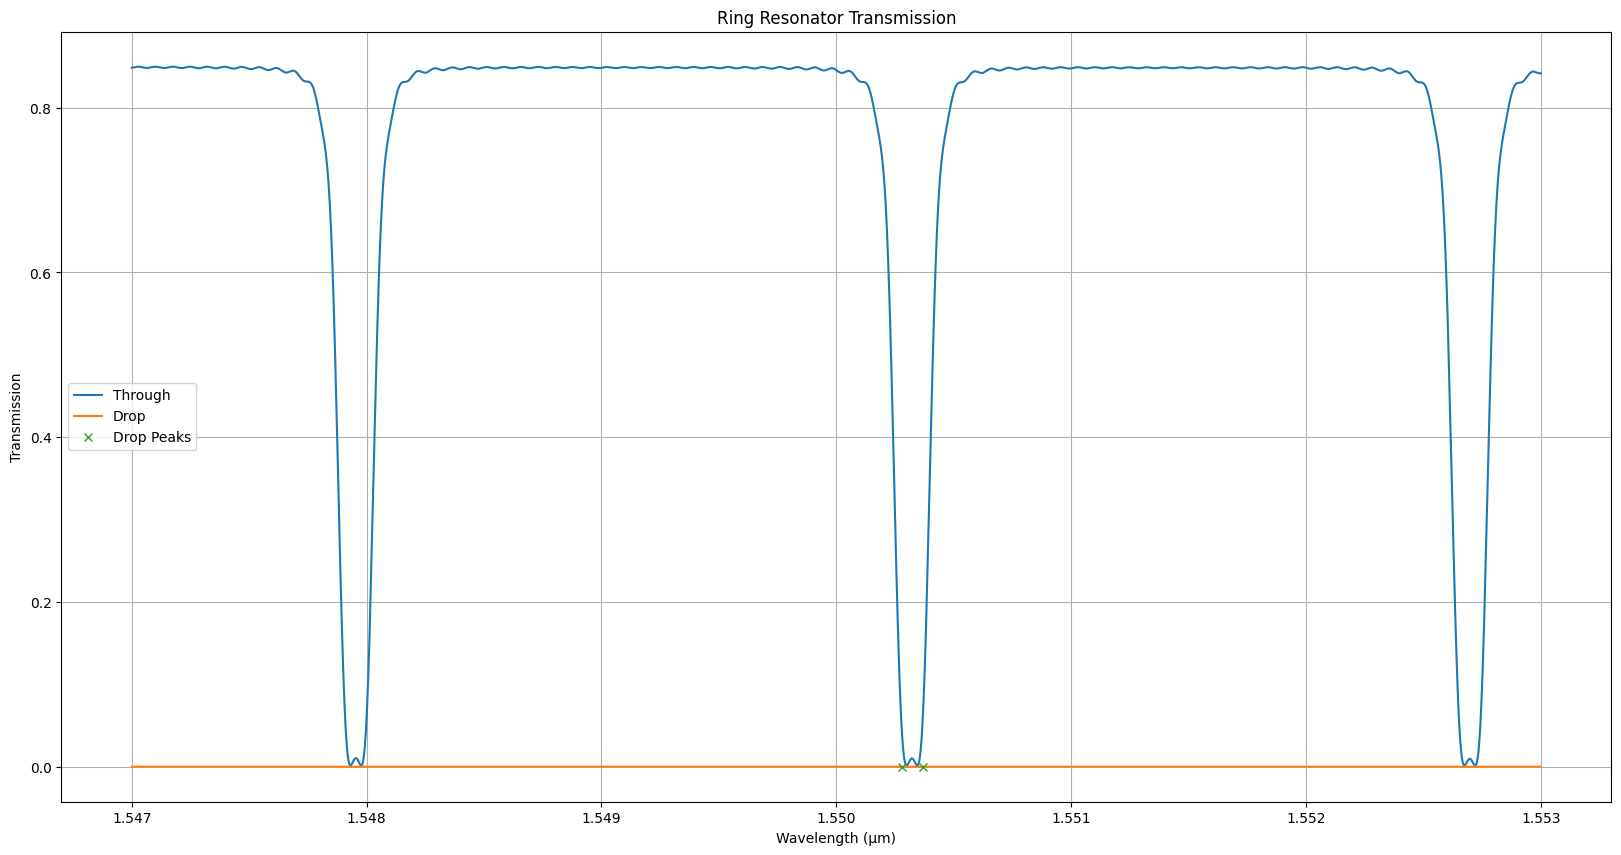

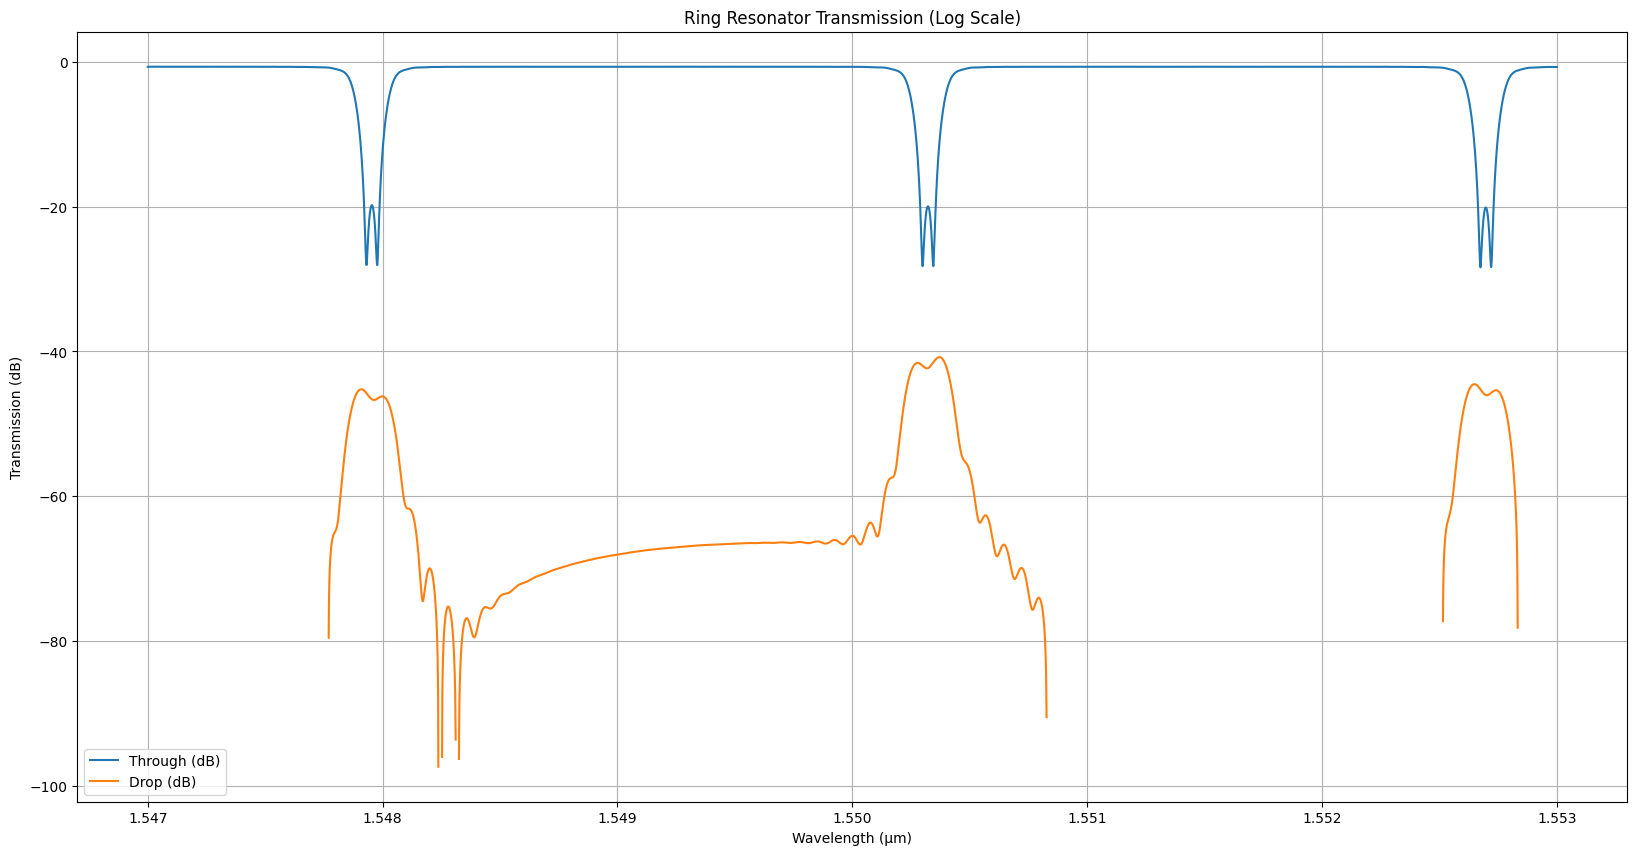

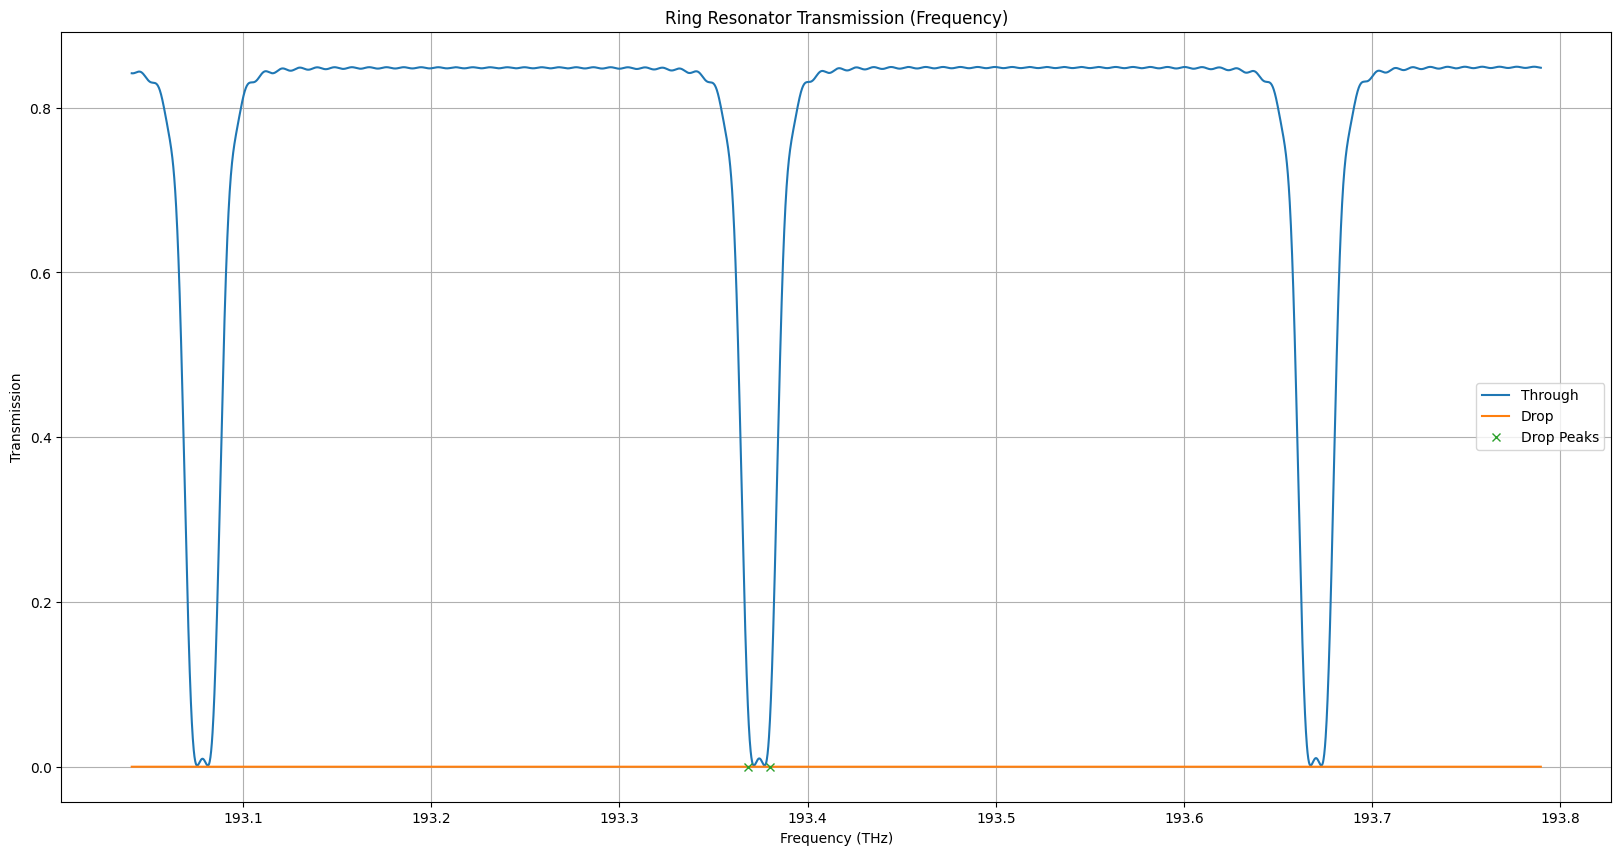

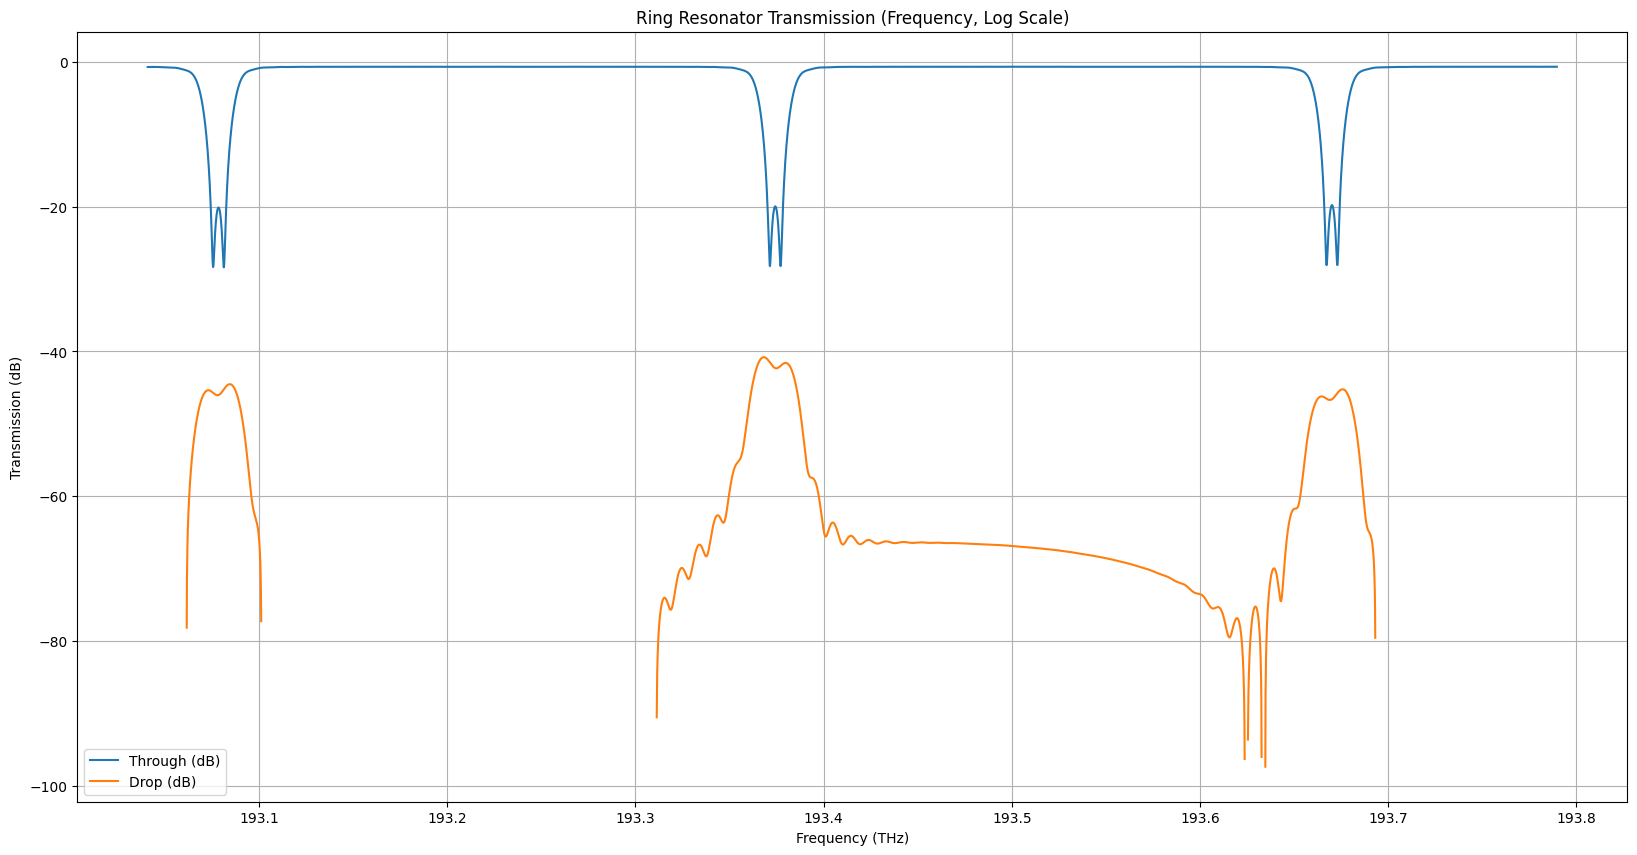

In [ ]:
#------------------------------------------------------------
# Save Data
#------------------------------------------------------------
from scipy.signal import find_peaks

# GET RELEVANT RESULTS
T_through = f.getresult("Through","T")
T_drop    = f.getresult("Drop","T")

Transmission_through = T_through['T'].flatten()
Transmission_drop    = -T_drop['T'].flatten()
Wavelength           = T_through['lambda'].flatten()
Frequency            = T_through['f'].flatten()

print(f"Wavelength range: {Wavelength[0]*1e9:.2f} nm to {Wavelength[-1]*1e9:.2f} nm")

# --- FSR Calculation ---
peaks, _ = find_peaks(Transmission_drop, height=0.5*np.max(Transmission_drop), distance=5)

peak_wavelengths = Wavelength[peaks]
if len(peak_wavelengths) >= 2:
    print("Peaks:", peak_wavelengths*1e9)
    FSRs = np.abs(np.diff(peak_wavelengths))
    avg_FSR = np.mean(FSRs)
    print(f"Average FSR: {avg_FSR*1e9:.2f} nm")

# --- Wavelength plot ---
plt.figure(figsize=(20,10))
plt.plot(Wavelength*1e6, Transmission_through, label='Through')
plt.plot(Wavelength*1e6, Transmission_drop, label='Drop')
plt.plot(Wavelength[peaks]*1e6, Transmission_drop[peaks], "x", label='Drop Peaks')
plt.xlabel("Wavelength (µm)")
plt.ylabel("Transmission")
plt.title("Ring Resonator Transmission")
plt.legend()
plt.grid()

# --- Wavelength plot (dB) ---
plt.figure(figsize=(20,10))
plt.plot(Wavelength*1e6, 10*np.log10(Transmission_through), label='Through (dB)')
plt.plot(Wavelength*1e6, 10*np.log10(Transmission_drop),    label='Drop (dB)')
plt.xlabel("Wavelength (µm)")
plt.ylabel("Transmission (dB)")
plt.title("Ring Resonator Transmission (Log Scale)")
plt.legend()
plt.grid()

# --- Frequency plot ---
plt.figure(figsize=(20,10))
plt.plot(Frequency*1e-12, Transmission_through, label='Through')
plt.plot(Frequency*1e-12, Transmission_drop, label='Drop')
plt.plot(Frequency[peaks]*1e-12, Transmission_drop[peaks], "x", label='Drop Peaks')
plt.xlabel("Frequency (THz)")
plt.ylabel("Transmission")
plt.title("Ring Resonator Transmission (Frequency)")
plt.legend()
plt.grid()

# --- Frequency plot (dB) ---
plt.figure(figsize=(20,10))
plt.plot(Frequency*1e-12, 10*np.log10(Transmission_through), label='Through (dB)')
plt.plot(Frequency*1e-12, 10*np.log10(Transmission_drop),    label='Drop (dB)')
plt.xlabel("Frequency (THz)")
plt.ylabel("Transmission (dB)")
plt.title("Ring Resonator Transmission (Frequency, Log Scale)")
plt.legend()
plt.grid()

In [ ]:
# --- Header ---
header = f"""Gap_nm={GapIO*1e9:.2f}
Width_nm={Width*1e9:.2f}
Height_nm={Height*1e9:.2f}
CouplingLengthX_um={CouplingLengthX*1e6:.2f}
CouplingLengthY_um={CouplingLengthY*1e6:.2f}
Radius_um={Radius*1e6:.2f}
Material={Material}
SimTime_ps={SimulationTime*1e12:.2f}
FrequencyPoints={FrequencyPoints}
LambdaStart_nm={LambdaStart*1e9:.2f}
LambdaStop_nm={LambdaStop*1e9:.2f}

Wavelength_um\tFrequency_THz\tTransmission_Through\tTransmission_Drop
"""

# --- Filename ---
filename = (
    f"Data_{LumFileName.removesuffix('.lms')}_"
    f"CLx_{CouplingLengthX*1e6:.1f}um_CLy_{CouplingLengthY*1e6:.1f}um_"
    f"R{Radius*1e6:.1f}um_"
    f"LambdaRange{int(LambdaStart*1e9)}-{int(LambdaStop*1e9)}nm_"
    f"GapIO{GapIO*1e9:.0f}nm_Tx.txt"
    f"GapRing{GapRing*1e9:.0f}nm_Tx.txt"
)

filepath = data_save_dir / filename

# --- Data ---
data = np.column_stack((
    Wavelength * 1e6,
    Frequency * 1e-12,
    Transmission_through,
    Transmission_drop
))

np.savetxt(
    filepath,
    data,
    delimiter='\t',
    header=header,
    comments='# ',
    fmt='%.6e'
)

print(f"Data saved to {filepath}")

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_QuantumComb\Data_RingMOD_Squeez_CLx_0.0um_CLy_0.0um_R100.0um_LambdaRange1547-1553nm_GapIO500nm_Tx.txt
